In [1]:
import xarray as xr
import isku_utils
import cdsapi

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os

load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]

# API Data Download

In [ ]:
### Projection ###

dataset = "projections-climate-atlas"
request = {
    "origin": "cmip6",
    "experiment": "ssp2_4_5",
    "domain": "global",
    "period": "2015-2100",
    "variable": "monthly_mean_of_daily_mean_temperature",
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/cmip6_2015_2100_monthly_tmean_ssp245.nc")

In [ ]:
### Historical ###
dataset = "projections-climate-atlas"
request = {
    "origin": "cmip6",
    "experiment": "historical",
    "domain": "global",
    "period": "1850-2014",
    "variable": "monthly_mean_of_daily_mean_temperature",
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/cmip6_hist_1850_2014_monthly_tmean.nc")

In [ ]:
## Monthly Hindcast
import cdsapi

dataset = "seasonal-monthly-single-levels"
request = {
    "originating_centre": "ecmwf",
    "system": "51",
    "variable": ["2m_temperature"],
    "product_type": ["monthly_mean"],
    "year": [
        "1981",
        "1982",
        "1983",
        "1984",
        "1985",
        "1986",
        "1987",
        "1988",
        "1989",
        "1990",
        "1991",
        "1992",
        "1993",
        "1994",
        "1995",
        "1996",
        "1997",
        "1998",
        "1999",
        "2000",
        "2001",
        "2002",
        "2003",
        "2004",
        "2005",
        "2006",
        "2007",
        "2008",
        "2009",
        "2010",
        "2011",
        "2012",
        "2013",
        "2014",
    ],
    "month": ["07"],
    "leadtime_month": ["1", "2", "3", "4", "5", "6"],
    "data_format": "netcdf",
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/seas5_1981_2014_monthly_tmean_2.nc")

In [ ]:
## Monthly Forecast
dataset = "seasonal-monthly-single-levels"
request = {
    "originating_centre": "ecmwf",
    "system": "51",
    "variable": ["2m_temperature"],
    "product_type": ["monthly_mean"],
    "year": ["2026"],
    "month": ["07"],
    "leadtime_month": ["1", "2", "3", "4", "5", "6"],
    "data_format": "netcdf",
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/seas5_202607_monthly_tmean.nc")

# Data Processing

In [ ]:
import zipfile

with zipfile.ZipFile("./data/seas5_1981_2014_monthly_tmean_2.nc") as z:
    z.extractall("./data/")

In [ ]:
with zipfile.ZipFile("./data/seas5_1981_2014_monthly_tmean.nc") as z:
    print(z.namelist())

# Load Data

In [2]:
# Define Forecast Months
fc_months = [8, 9, 10, 11, 12, 1]

In [3]:
## CMIP6 Projections
ar6_project = xr.open_dataset(
    os.path.join(DATA_DIR, "t_CMIP6_ssp370_mon_201501-210012.nc"),
    chunks={"member": -1, "time": -1, "lat": 30, "lon": 30},
)
ar6_hist = xr.open_dataset(
    os.path.join(DATA_DIR, "t_CMIP6_historical_mon_185001-201412.nc"),
    chunks={"member": -1, "time": -1, "lat": 30, "lon": 30},
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/conventions.py:205: SerializationWarning: variable 't' has multiple fill values {np.float32(1.0384594e+34), np.float32(-1.7014118e+38)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/tmp/ipykernel_70751/446899937.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ar6_project = xr.open_dataset(os.path.join(DATA_DIR,"t_CMIP6_ssp370_mon_201501-210012.nc"), chunks={"member": -1, "time": -1, "lat": 30, "lon": 30})
/tmp/ipykernel_70751/446899937.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ar6_project = xr.open_dataset(os.path.join(DATA_DIR,"t_CMIP6_ssp370_mon_201501-210012.nc"), chunks={"member": -1, "time"

In [4]:
# IPCC Recent Baseline Period 1995-2014
hist_mean = (
    ar6_hist["t"]
    .sel(time=slice("1995-01-01", "2014-12-31"))
    .groupby("time.month")
    .mean()
)
hist_mean = hist_mean.sel(month=fc_months).mean(dim="member").compute()

In [5]:
projection = ar6_project["t"]
projection = projection.assign_coords(
    year=projection.time.dt.year, month=projection.time.dt.month
)
projection = projection.set_index(time=["year", "month"]).unstack("time")
projection = projection.sel(month=fc_months).mean(dim=["member"]).compute()

In [6]:
### Seasonal Forecast ###
# Raw Forecast/Hindcast
s51 = xr.open_zarr(
    "/home/emily_zuetell/projects/poreallas/data/parsed/08_ecmwf_parsed.zarr"
)
forecast = (
    s51.sel(time=slice("2026-08-01", "2027-01-31"))
    .groupby("time.month")
    .mean()
    .compute()
)
hindcast = (
    s51.sel(time=slice("1995-08-01", "2014-01-31"))
    .groupby("time.month")
    .mean()
    .sel(month=[1, 8, 9, 10, 11, 12])
    .mean(dim="number")
    .compute()
)

### Distributions + Testing (Deprecated 8/14/26)

In [8]:
## Statistics ##
# Climate Projection
mean_proj = projection.mean(dim="member")
var_proj = (projection.std(dim="member")) ** 2
n_proj = len(projection.member)

mean_base = hist_mean.mean(dim="member")
var_base = (hist_mean.std(dim="member")) ** 2
n_base = len(hist_mean.member)

anomaly_proj = mean_proj - mean_base
# Rolling avg
anomaly_proj = anomaly_proj.rolling(year=5, center=False, min_periods=5).mean()
var_anomaly_proj = (var_proj / n_proj) + (var_base / n_base)

# Seasonal Forecast
mean_fc = forecast["t2m"].mean(dim="number")
var_fc = forecast["t2m"].var(dim="number")
n_fc = len(forecast["t2m"].number)

mean_hc = hindcast["t2m"].mean(dim="number")
var_hc = hindcast["t2m"].var(dim="number")
n_hc = len(hindcast["t2m"].number)

anomaly_fc = mean_fc - mean_hc
var_anomaly_fc = (var_fc / n_fc) + (var_hc / n_hc)

In [12]:
## Probability of Surpassing Projection Anomaly
diff = anomaly_fc - anomaly_proj
var_diff = var_anomaly_fc + var_anomaly_proj
# var_diff = var_anomaly_fc #Forecast uncertainty only (No projection uncertainty)
z = diff / np.sqrt(var_diff)
p_surpass = xr.apply_ufunc(norm.cdf, z)

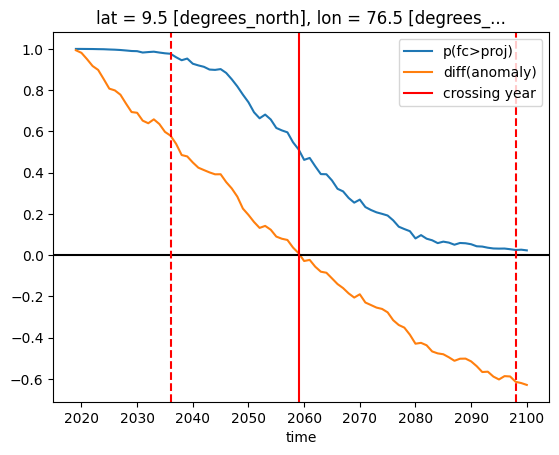

In [15]:
# lat, lon = 42, 49
lat, lon = 9.9312, 76.2673
fig, ax = plt.subplots()
p_surpass.sel(lat=lat, lon=lon, method="nearest").plot(ax=ax, label="p(fc>proj)")
diff.sel(lat=lat, lon=lon, method="nearest").plot(ax=ax, label="diff(anomaly)")
ax.axhline(0, color="k")
ax.axvline(
    p_surpass.sel(lat=lat, lon=lon, method="nearest")
    .where(p_surpass.sel(lat=lat, lon=lon, method="nearest") >= 0.5)
    .idxmin("year"),
    color="red",
    label="crossing year",
)
ax.axvline(
    p_surpass.sel(lat=lat, lon=lon, method="nearest")
    .where(p_surpass.sel(lat=lat, lon=lon, method="nearest") >= 0.025)
    .idxmin("year"),
    color="red",
    linestyle="--",
)
ax.axvline(
    p_surpass.sel(lat=lat, lon=lon, method="nearest")
    .where(p_surpass.sel(lat=lat, lon=lon, method="nearest") >= 0.975)
    .idxmin("year"),
    color="red",
    linestyle="--",
)
ax.legend()

# Empirical - Decade Basis

In [ ]:
## Clean statistics
projection = projection.interpolate_na(dim="lat", method="linear")
hist_mean = hist_mean.interpolate_na(dim="lat", method="linear")
## Statistics ##
# Climate Projection
mean_proj = projection.mean(dim="month")
mean_base = hist_mean.mean(dim="month")

anomaly_proj = mean_proj - mean_base
# Rolling avg
anomaly_proj_smooth = anomaly_proj.rolling(year=10, center=False, min_periods=10).mean()

ds1 = anomaly_proj_smooth
decade1 = ((ds1["year"] // 10) * 10).rename("decade")
# Enforce monotonically increasing projection
decade_min = ds1.groupby(decade1).min().cumulative("decade").min()
decade_max = ds1.groupby(decade1).max().cumulative("decade").max()

In [ ]:
ds2 = forecast["tas"] - hindcast["tas"]
ds2 = ds2.mean(dim="month")
ds2 = isku_utils.lon_adjust(ds2, roll=True)

in_range = (ds2 >= (decade_min)) & (ds2 <= (decade_max))
below = ds2 <= decade_min.min("decade")
above = ds2 >= decade_max.max("decade")

mode_decade = in_range.where(in_range == True).idxmin("decade").compute()

da = xr.where(below, 2010, xr.where(above, 2110, mode_decade)).compute()

In [114]:
from scipy import stats

# Ensemble Stats
median = da.median(dim="number")

mode = xr.apply_ufunc(
    lambda x: stats.mode(x, axis=-1, keepdims=False).mode,
    da,
    input_core_dims=[["number"]],
    vectorize=True,
)
mode_count = xr.apply_ufunc(
    lambda x: stats.mode(x, axis=-1, keepdims=False).count,
    da,
    input_core_dims=[["number"]],
    vectorize=True,
)

### Empirical Crossing Year (Deprecated 8/14/26)

In [21]:
# Empirical Version
# Climate Projection
mean_proj = projection.mean(dim="member")
mean_base = hist_mean.mean(dim="member")
anomaly_proj = mean_proj - mean_base

anomaly_proj = anomaly_proj.rolling(year=5, center=False, min_periods=5).mean()
emp_diff = forecast["t2m"] - hindcast["t2m"] - anomaly_proj
years_emp = emp_diff.where(emp_diff <= 0).idxmax("year")

# Save Out
quantiles = years_emp.quantile([0.1, 0.5, 0.9], dim="number")
crossing_year = quantiles.sel(quantile=0.5).drop_vars("quantile")
ci_low = quantiles.sel(quantile=0.1).drop_vars("quantile")
ci_high = quantiles.sel(quantile=0.9).drop_vars("quantile")
ci_low = ci_low.fillna(2014)
ci_high = ci_high.fillna(2101)

ci_width = ci_high - ci_low

ds_out = xr.Dataset(
    {
        "crossing_year": crossing_year,
        "ci_width_95": ci_width,
        "ci_10": ci_low,
        "ci_90": ci_high,
    }
)

# ds_out.to_zarr('./data/2607_fc_anomaly_year_fcvarOnly_emp_ssp245.zarr')

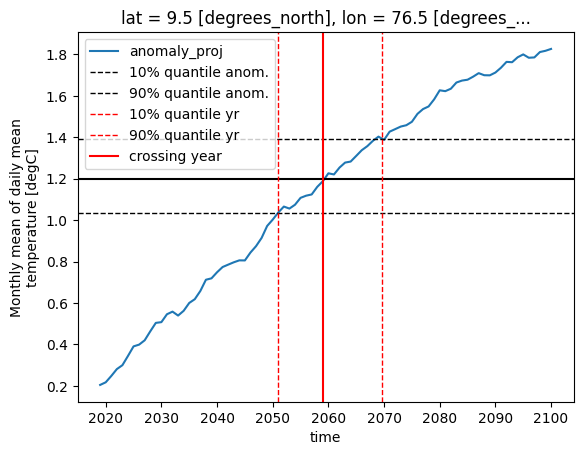

In [17]:
# lat, lon = 42, 49
lat, lon = 9.9312, 76.2673
fig, ax = plt.subplots()
data = (forecast["t2m"] - hindcast["t2m"]).sel(lat=lat, lon=lon, method="nearest")
anomaly_proj.sel(lat=lat, lon=lon, method="nearest").plot(ax=ax, label="anomaly_proj")

ax.axhline(anomaly_fc.sel(lat=lat, lon=lon, method="nearest"), color="k")

quantiles = data.quantile([0.1, 0.9], dim="number")
for q, val in zip(quantiles["quantile"].values, quantiles.values):
    ax.axhline(
        val, color="k", linestyle="--", linewidth=1, label=f"{q:.0%} quantile anom."
    )

quantiles = years_emp.sel(lat=lat, lon=lon, method="nearest").quantile(
    [0.1, 0.9], dim="number"
)
for q, val in zip(quantiles["quantile"].values, quantiles.values):
    ax.axvline(
        val, color="red", linestyle="--", linewidth=1, label=f"{q:.0%} quantile yr"
    )


ax.axvline(
    p_surpass.sel(lat=lat, lon=lon, method="nearest")
    .where(p_surpass.sel(lat=lat, lon=lon, method="nearest") >= 0.5)
    .idxmin("year"),
    color="red",
    label="crossing year",
)
ax.legend()

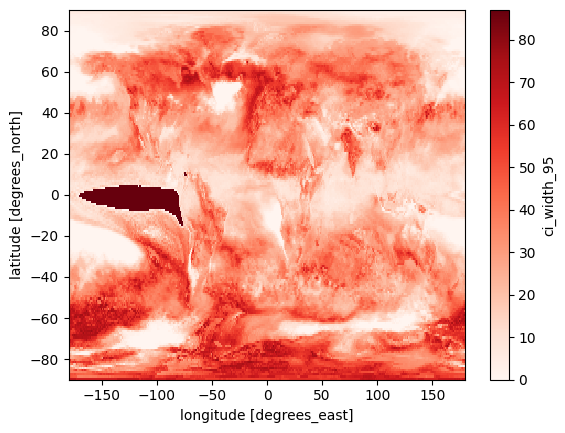

In [18]:
ds_out["ci_width_95"].plot(cmap="Reds", vmin=0)

# Final Data

In [53]:
import analysis_utils
import geopandas as gpd

load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]

# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

In [61]:
# Log forecast anomaly
fc_anomaly = isku_utils.grid_to_ir(ds2)
fc_anomaly_df = analysis_utils.xarray_to_gpd(fc_anomaly, _polygons)
fc_anomaly_df["value"].to_csv("2608_fc_anomaly.csv")

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [115]:
data_ir_mode = isku_utils.grid_to_ir(mode)
data_ir_median = isku_utils.grid_to_ir(median)
data_ir_counts = isku_utils.grid_to_ir(mode_count)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

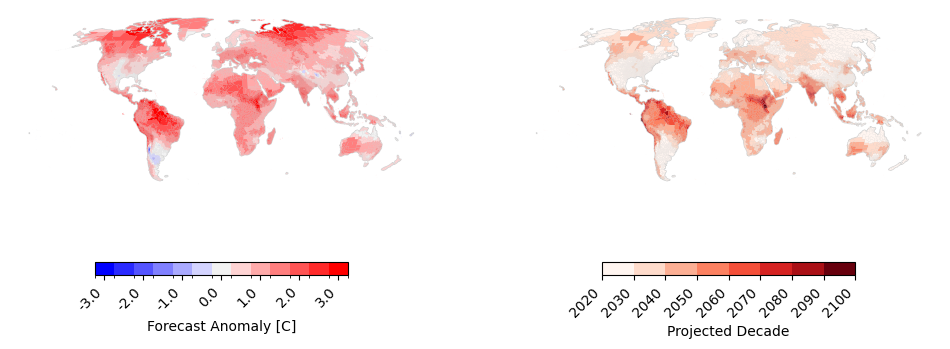

In [62]:
_polygons_postcard_median = analysis_utils.xarray_to_gpd(data_ir_median, _polygons)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
analysis_utils.plot_single(
    _polygons_postcard_median,
    col="value",
    cm="Reds",
    vmin=2020,
    vmax=2100,
    cbar_label="Projected Decade",
    ax=axs[1],
    cbar_location="bottom",
)

analysis_utils.plot_single(
    fc_anomaly_df,
    col="value",
    cm="bwr",
    n_colors=13,
    cbar_label="Forecast Anomaly [C]",
    ax=axs[0],
    cbar_location="bottom",
)

fig.savefig("2608_combined_anomaly_postcard", dpi=600, bbox_inches="tight")

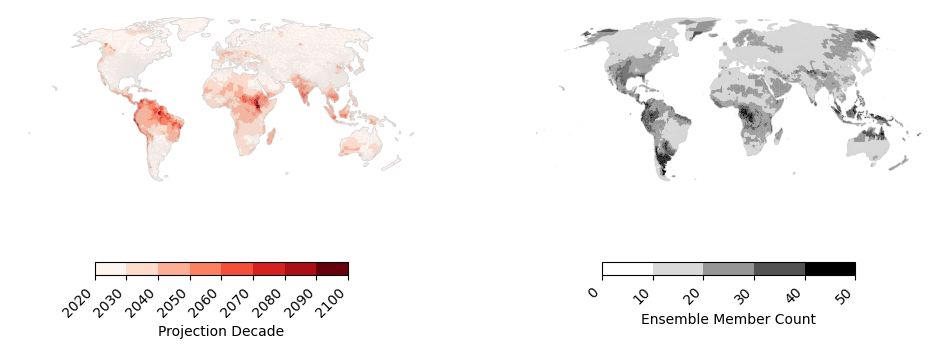

In [67]:
_polygons_postcard_mode = analysis_utils.xarray_to_gpd(data_ir_mode, _polygons)
_polygons_postcard_count = analysis_utils.xarray_to_gpd(data_ir_counts, _polygons)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
analysis_utils.plot_single(
    _polygons_postcard_mode,
    col="value",
    cm="Reds",
    vmin=2020,
    vmax=2100,
    cbar_label="Projection Decade",
    ax=axs[0],
    cbar_location="bottom",
)

analysis_utils.plot_single(
    _polygons_postcard_count,
    col="value",
    cm="Grays",
    vmin=0,
    vmax=50,
    cbar_label="Ensemble Member Count",
    ax=axs[1],
    cbar_location="bottom",
)

fig.savefig("2608_combined_spread_postcard", dpi=600, bbox_inches="tight")

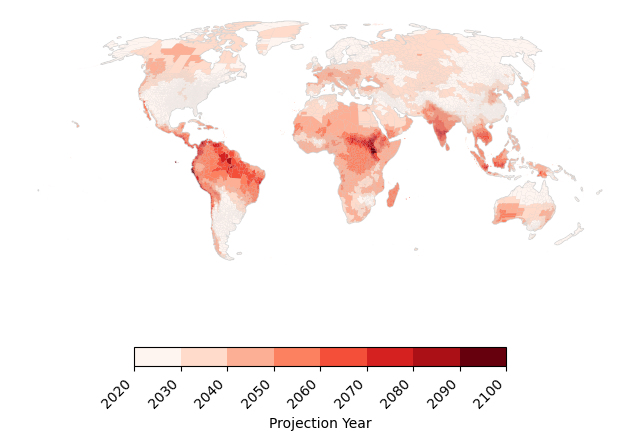

In [55]:
_polygons_postcard_median = analysis_utils.xarray_to_gpd(data_ir_median, _polygons)
ax = analysis_utils.plot_single(
    _polygons_postcard_median,
    col="value",
    cm="Reds",
    vmin=2020,
    vmax=2100,
    cbar_label="Projection Year",
    cbar_location="bottom",
)

fig = ax.get_figure()
fig.savefig("2608_postcard.png", dpi=600, bbox_inches="tight")

In [58]:
# df_out = _polygons_postcard[['region', 'value']].rename(columns={"value": "year"}).assign(mode_members=_polygons_postcard_count['value'])
df_out = _polygons_postcard_median[["region", "value"]].rename(
    columns={"value": "year"}
)
df_out.to_csv("2608_postcard_median_10yrroll.csv")

In [59]:
len(df_out[df_out["year"] < 2010])

0

# Climate Projections

In [113]:
ds2 = forecast["t2m"] * 0 + 1.5
in_range = (ds2 >= decade_min) & (ds2 <= decade_max)
below = ds2 < decade_min.min("decade")
above = ds2 > decade_max.max("decade")

mode_decade = in_range.where(in_range == True).idxmin("decade").compute()

da = xr.where(below, 2020, xr.where(above, 2110, mode_decade)).compute()
data_ir = isku_utils.grid_to_ir(da)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:31: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [114]:
_polygons_postcard = analysis_utils.xarray_to_gpd(data_ir, _polygons)

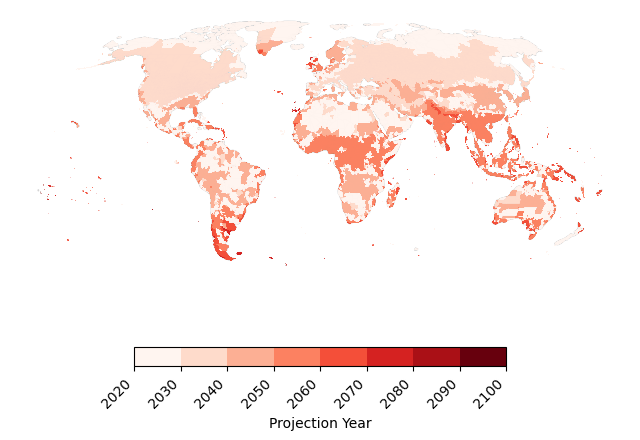

In [115]:
ax = analysis_utils.plot_single(
    _polygons_postcard,
    col="value",
    cm="Reds",
    vmin=2020,
    vmax=2100,
    cbar_label="Projection Year",
    cbar_location="bottom",
)

fig = ax.get_figure()
fig.savefig("2607_postcard_projection_15", dpi=600, bbox_inches="tight")

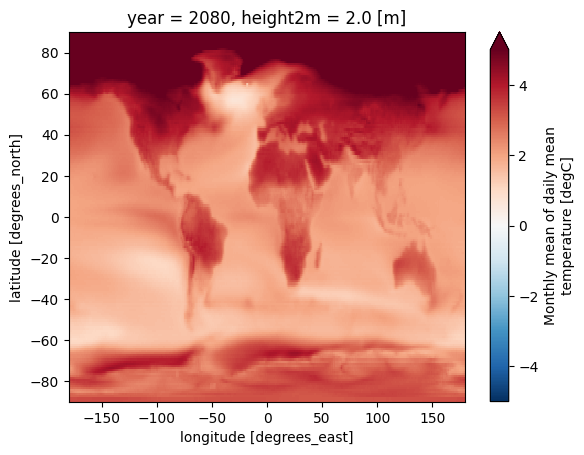

In [103]:
anomaly_proj.sel(year=2080).plot(cmap="RdBu_r", vmin=-5, vmax=5)

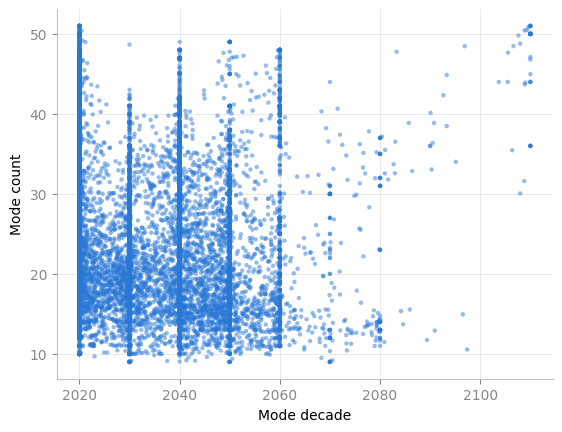

In [87]:
x = _polygons_postcard["value"][_polygons_postcard["value"] > 2019]
y = _polygons_postcard_count["value"][_polygons_postcard["value"] > 2019]
mask = np.isfinite(x) & np.isfinite(y)

fig, ax = plt.subplots()
ax.scatter(x[mask], y[mask], s=10, color="#2a78d6", alpha=0.5, edgecolors="none")
ax.set_xlabel("Mode decade")
ax.set_ylabel("Mode count")
ax.grid(color="#e1e0d9", linewidth=0.5)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")
ax.tick_params(colors="#898781")